In [26]:
import pandas as pd
import numpy as np
import matplotlib as mplb
import seaborn as sns
import scypy as sp
import sklearn
import matplotlib.pyplot as plt

# Basics

### Loading data

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
from sklearn.datasets import fetch_california_housing


data = fetch_california_housing()
X = data.data
y = data.target

In [19]:
from sklearn.neighbors import KNeighborsRegressor

### Creating model

In [20]:
mod = KNeighborsRegressor()

### Teaching model

In [21]:
mod.fit(X, y)

KNeighborsRegressor()

In [30]:
result = mod.predict(X=X)

In [33]:
linear_model = LinearRegression()
linear_model.fit(X=X, y=y)
lin_res = linear_model.predict(X=X)

<Axes: >

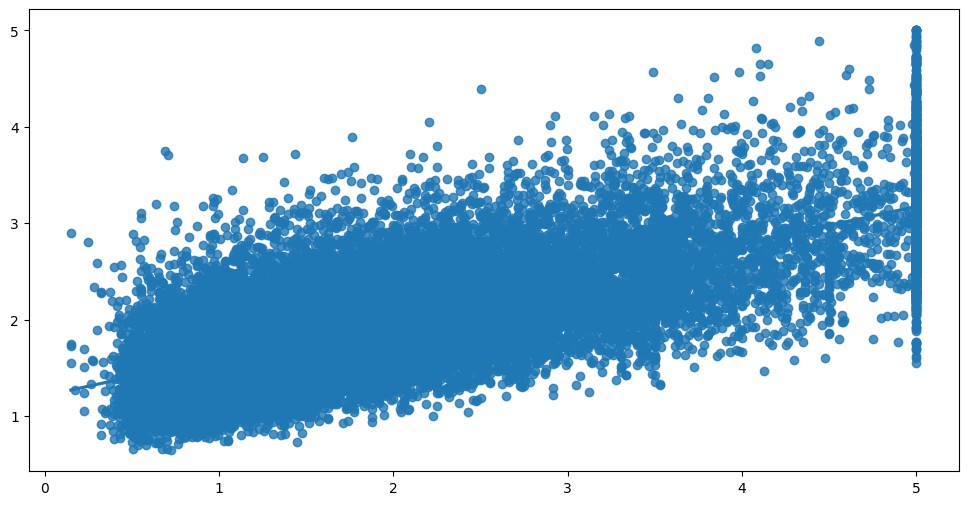

In [32]:
plt.figure(figsize=(12, 6))
sns.regplot(x=y, y=result)

<Axes: >

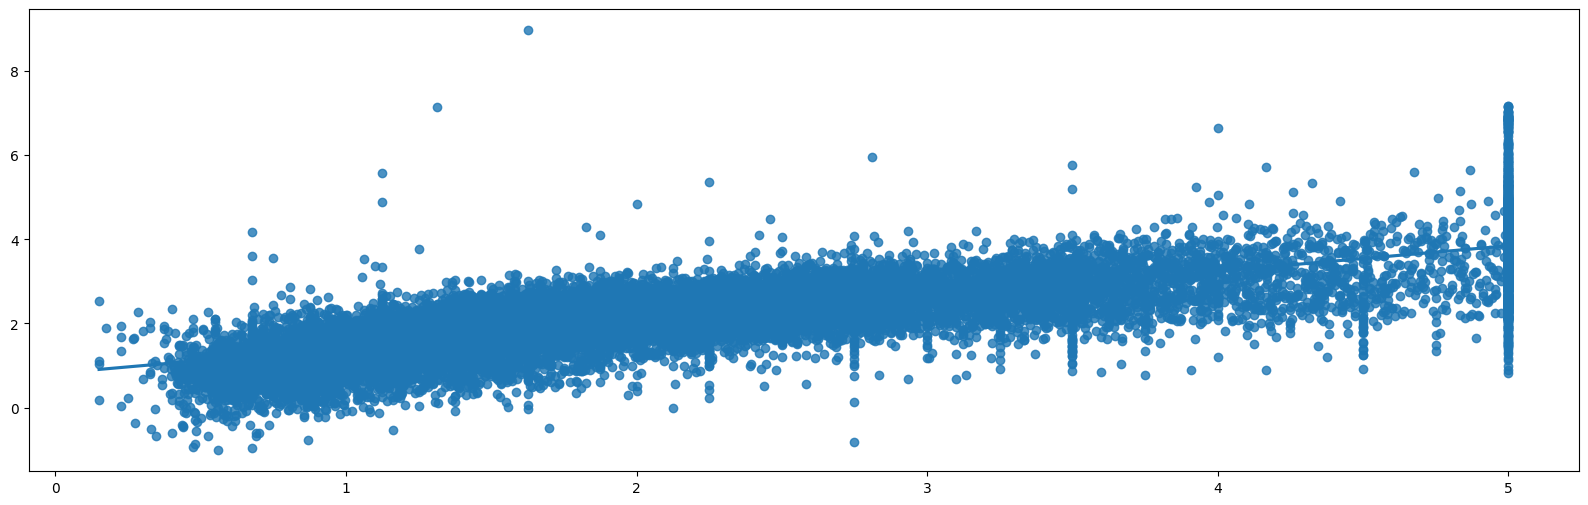

In [35]:
plt.figure(figsize=(20, 6))
sns.regplot(x=y, y=lin_res)

### Implementing scale into the pipeline

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [43]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

pipe.fit(X=X, y=y)

Pipeline(steps=[('scale', StandardScaler()), ('model', KNeighborsRegressor())])

<Axes: >

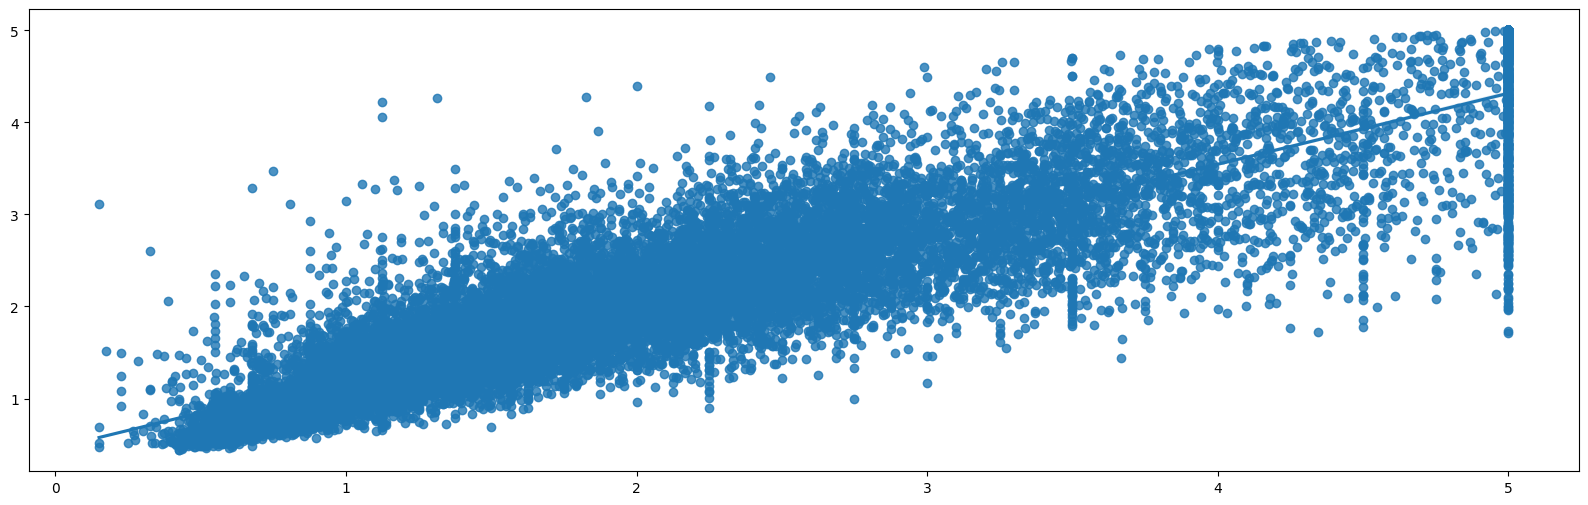

In [44]:
plt.figure(figsize=(20, 6))
sns.regplot(x=y, y=pipe.predict(X=X))

### Implementing GridSearch

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
pipe.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()), ('model', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [70]:
grid_model = GridSearchCV(
    estimator=pipe, 
    param_grid={"model__n_neighbors":[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
    cv=3 # cross-validation
).fit(X=X, y=y)

In [50]:
pd.DataFrame(grid_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005923,0.002292,0.122495,0.012375,1,{'model__n_neighbors': 1},0.324068,0.334830,0.323371,0.327423,0.005245,10
1,0.004763,0.000329,0.127695,0.009817,2,{'model__n_neighbors': 2},0.468788,0.503457,0.424388,0.465544,0.032361,9
2,0.004172,0.000143,0.137977,0.011240,3,{'model__n_neighbors': 3},0.518547,0.543340,0.473595,0.511827,0.028867,8
3,0.004114,0.000178,0.145244,0.011332,4,{'model__n_neighbors': 4},0.540323,0.564974,0.499827,0.535041,0.026857,7
4,0.004490,0.000188,0.151195,0.010961,5,{'model__n_neighbors': 5},0.551149,0.579313,0.511781,0.547414,0.027696,6
5,0.004230,0.000058,0.157410,0.010744,6,{'model__n_neighbors': 6},0.558435,0.586185,0.521134,0.555251,0.026652,5
6,0.004154,0.000073,0.162738,0.011558,7,{'model__n_neighbors': 7},0.564207,0.590509,0.525223,0.559979,0.026820,4
7,0.004254,0.000249,0.167505,0.013053,8,{'model__n_neighbors': 8},0.568637,0.593942,0.529337,0.563972,0.026580,3
8,0.004260,0.000209,0.171303,0.011119,9,{'model__n_neighbors': 9},0.571972,0.594863,0.529928,0.565588,0.026891,2
9,0.004175,0.000048,0.175239,0.010848,10,{'model__n_neighbors': 10},0.573760,0.595831,0.532973,0.567522,0.026038,1


In [52]:
print(fetch_california_housing()['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

# Pre-processing

In [56]:
data = pd.read_csv("drawndata1.csv")
data.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


<Axes: xlabel='x', ylabel='y'>

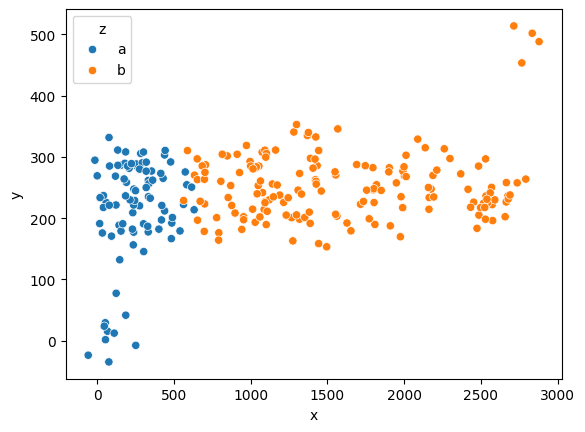

In [57]:
sns.scatterplot(x=data.x, y=data.y, hue=data.z)

<Axes: >

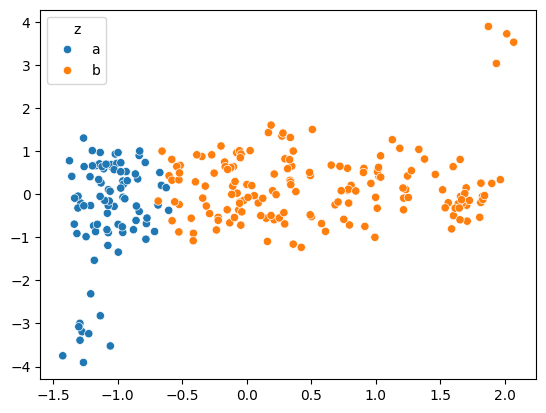

In [84]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.linear_model import LogisticRegression
X_transformed = StandardScaler().fit_transform(X=data[["x", "y"]])
sns.scatterplot(x=X_transformed[:, 0], y=X_transformed[:, 1], hue=data.z)

/Users/karlkorhonen/проекты/Python/Python_guides/venv/lib/python3.9/site-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


<Axes: >

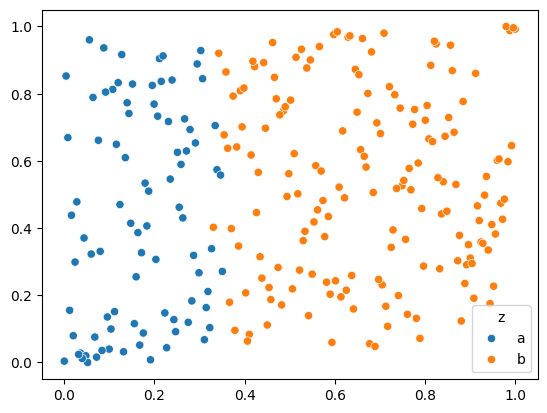

In [ ]:
X_quant_transformed = QuantileTransformer(n_quantiles=100).fit_transform(X=data[["x", "y"]])
sns.scatterplot(x=X_quant_transformed[:, 0], y=X_quant_transformed[:, 1], hue=data.z)

In [86]:
quant_pipe = Pipeline([
    ("scale", QuantileTransformer(n_quantiles=100)),
    ("model", LogisticRegression())
])


#### Working with new dataset


In [91]:
df2 = pd.read_csv(
    "drawndata2.csv"
)
df2

,x,y,z
0,469.759355,453.574946,a
1,535.331819,435.221848,a
2,504.285526,437.767578,a
3,469.891398,368.371652,a
4,405.425622,403.141546,a
...,...,...,...
212,600.143988,80.491534,b
213,568.999685,83.044558,b
214,618.746701,76.644596,b
215,623.827439,33.224234,b


In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


quant_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression())
])

param_grid = {
    "poly__degree": [1, 2, 3],
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(quant_pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X=df2[['x', 'y']], y=df2['z'])

print("Лучшие параметры:", grid.best_params_)
print("Лучший результат:", grid.best_score_)



Лучшие параметры: {'model__C': 10, 'poly__degree': 3}
Лучший результат: 0.976955602536998


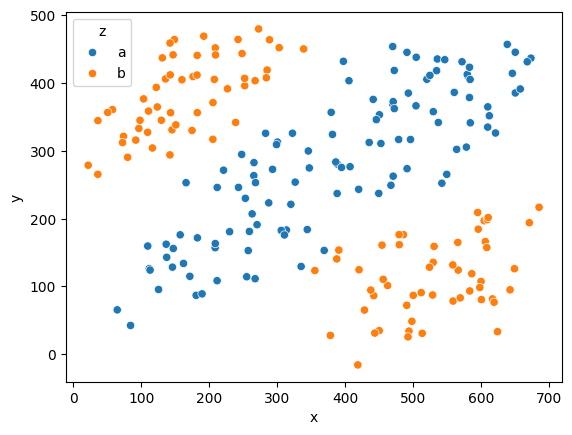

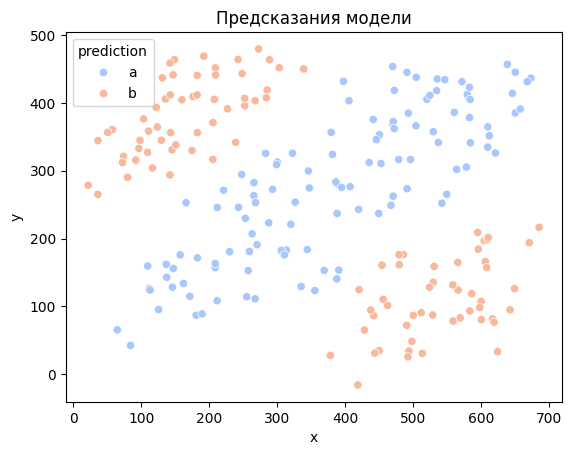

In [105]:
quant_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression())
]).fit(X=df2[['x', 'y']], y=df2['z'])


sns.scatterplot(
    x=df2['x'],
    y=df2['y'],
    hue=df2['z'],
)
plt.show()
plt.close()

total_df = pd.concat((
    df2[['x', 'y']].copy(),
    pd.Series(quant_pipe.predict(df2[['x', 'y']]), name='prediction')
), axis=1)

sns.scatterplot(
    x=total_df['x'],
    y=total_df['y'],
    hue=total_df['prediction'],
    palette='coolwarm'
)
plt.title("Предсказания модели")
plt.show()
plt.close()


In [114]:
datum = np.array(["low", "medium", "high"]*10).reshape((-1, 1))
datum

array([['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high'],
       ['low'],
       ['medium'],
       ['high']], dtype='<U6')

In [119]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit_transform(datum)

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

## Model examples

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# Классификация: пример на breast cancer
X_cls, y_cls = load_breast_cancer(return_X_y=True)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

# Регрессия: пример на diabetes
X_reg, y_reg = load_diabetes(return_X_y=True)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

### Classification

In [135]:
# 1. Логистическая регрессия
from sklearn.linear_model import LogisticRegression
clf_logreg = LogisticRegression(max_iter=1000)
clf_logreg.fit(X_train_cls, y_train_cls)
print("LogReg acc:", accuracy_score(y_test_cls, clf_logreg.predict(X_test_cls)))

# 2. Случайный лес
from sklearn.ensemble import RandomForestClassifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_cls, y_train_cls)
print("Random Forest acc:", accuracy_score(y_test_cls, clf_rf.predict(X_test_cls)))

# 3. Метод опорных векторов (SVM)
from sklearn.svm import SVC
clf_svc = SVC()
clf_svc.fit(X_train_cls, y_train_cls)
print("SVM acc:", accuracy_score(y_test_cls, clf_svc.predict(X_test_cls)))

# 4. K ближайших соседей
from sklearn.neighbors import KNeighborsClassifier
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(X_train_cls, y_train_cls)
print("KNN acc:", accuracy_score(y_test_cls, clf_knn.predict(X_test_cls)))

# 5. Градиентный бустинг
from sklearn.ensemble import GradientBoostingClassifier
clf_gb = GradientBoostingClassifier()
clf_gb.fit(X_train_cls, y_train_cls)
print("Gradient Boosting acc:", accuracy_score(y_test_cls, clf_gb.predict(X_test_cls)))

/Users/karlkorhonen/проекты/Python/Python_guides/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg acc: 0.9707602339181286
Random Forest acc: 0.9707602339181286
SVM acc: 0.935672514619883
KNN acc: 0.9590643274853801
Gradient Boosting acc: 0.9590643274853801


### Regression

In [ ]:

print("KNN RMSE:", mean_squared_error(y_test_reg, reg_knn.predict(X_test_reg), squared=False))

# 5. Градиентный бустинг
from sklearn.ensemble import GradientBoostingRegressor
reg_gb = GradientBoostingRegressor()
reg_gb.fit(X_train_reg, y_train_reg)
print("Gradient Boosting RMSE:", mean_squared_error(y_test_reg, reg_gb.predict(X_test_reg), squared=False))

## Metrics

In [136]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# Загружаем данные
X_reg, y_reg = load_diabetes(return_X_y=True)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# 1. Линейная регрессия
from sklearn.linear_model import LinearRegression
reg_lin = LinearRegression()
reg_lin.fit(X_train_reg, y_train_reg)
print("LinearReg RMSE:", root_mean_squared_error(y_test_reg, reg_lin.predict(X_test_reg)))

# 2. Случайный лес
from sklearn.ensemble import RandomForestRegressor
reg_rf = RandomForestRegressor(n_estimators=100, random_state=42)
reg_rf.fit(X_train_reg, y_train_reg)
print("RandomForest RMSE:", root_mean_squared_error(y_test_reg, reg_rf.predict(X_test_reg)))

# 3. SVM регрессия
from sklearn.svm import SVR
reg_svr = SVR()
reg_svr.fit(X_train_reg, y_train_reg)
print("SVR RMSE:", root_mean_squared_error(y_test_reg, reg_svr.predict(X_test_reg)))

# 4. K ближайших соседей
from sklearn.neighbors import KNeighborsRegressor
reg_knn = KNeighborsRegressor(n_neighbors=5)
reg_knn.fit(X_train_reg, y_train_reg)
print("KNN RMSE:", root_mean_squared_error(y_test_reg, reg_knn.predict(X_test_reg)))

# 5. Градиентный бустинг
from sklearn.ensemble import GradientBoostingRegressor
reg_gb = GradientBoostingRegressor()
reg_gb.fit(X_train_reg, y_train_reg)
print("Gradient Boosting RMSE:", root_mean_squared_error(y_test_reg, reg_gb.predict(X_test_reg)))

LinearReg RMSE: 53.120156070942706
RandomForest RMSE: 53.4756204518168
SVR RMSE: 67.27414213184606
KNN RMSE: 56.763702264183244
Gradient Boosting RMSE: 55.43998678517583


In [ ]:
import os
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

In [124]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [126]:
X = df.drop(columns=["Time", "Amount", "Class"])
y = df.Class.copy()

In [130]:
y.sum()

np.int64(492)

In [133]:
from sklearn.linear_model import LogisticRegression


mod = LogisticRegression(class_weight={0:1, 1:2})
res = mod.fit(X=X, y=y).predict(X)
res.sum()


np.int64(434)

#### Now we will use gridsearch to define which weights show the best performance

In [137]:
from sklearn.model_selection import GridSearchCV

In [139]:
grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid={
        'class_weight': [{0: 1, 1: v} for v in range(1, 10)]
    },
    cv=4,
    n_jobs=-1
)

grid.fit(X, y)

GridSearchCV(cv=4, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 2},
                                          {0: 1, 1: 3}, {0: 1, 1: 4},
                                          {0: 1, 1: 5}, {0: 1, 1: 6},
                                          {0: 1, 1: 7}, {0: 1, 1: 8},
                                          {0: 1, 1: 9}]})

In [143]:
from pprint import pprint
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.778871,0.074825,0.014992,0.005222,"{0: 1, 1: 1}","{'class_weight': {0: 1, 1: 1}}",0.999228,0.998890,0.999228,0.998919,0.999066,0.000162,9
1,0.800863,0.050253,0.018859,0.012847,"{0: 1, 1: 2}","{'class_weight': {0: 1, 1: 2}}",0.999270,0.999157,0.999171,0.999031,0.999157,0.000085,8
2,0.648861,0.225354,0.017937,0.012466,"{0: 1, 1: 3}","{'class_weight': {0: 1, 1: 3}}",0.999199,0.999256,0.999199,0.999115,0.999192,0.000050,7
3,0.548162,0.105194,0.005330,0.003170,"{0: 1, 1: 4}","{'class_weight': {0: 1, 1: 4}}",0.999214,0.999354,0.999242,0.999199,0.999252,0.000061,2
4,0.605922,0.049529,0.008934,0.005480,"{0: 1, 1: 5}","{'class_weight': {0: 1, 1: 5}}",0.999171,0.999396,0.999185,0.999199,0.999238,0.000092,3
5,0.614628,0.039249,0.014473,0.005798,"{0: 1, 1: 6}","{'class_weight': {0: 1, 1: 6}}",0.999143,0.999424,0.999214,0.999228,0.999252,0.000104,1
6,0.621934,0.043622,0.018884,0.014155,"{0: 1, 1: 7}","{'class_weight': {0: 1, 1: 7}}",0.999115,0.999424,0.999228,0.999157,0.999231,0.000118,4
7,0.656222,0.081303,0.010523,0.009273,"{0: 1, 1: 8}","{'class_weight': {0: 1, 1: 8}}",0.999059,0.999452,0.999199,0.999171,0.999221,0.000144,5
8,0.464357,0.059713,0.003160,0.000625,"{0: 1, 1: 9}","{'class_weight': {0: 1, 1: 9}}",0.999059,0.999480,0.999143,0.999157,0.999210,0.000161,6


### Scoring methods

Now, our metric shows how often we decide, that the transaction is not a fraud

In [ ]:
scoring_classification = [
    "accuracy",              # Доля правильных ответов
    "balanced_accuracy",     # Усреднённая accuracy по классам (учитывает дисбаланс)
    "precision",             # Precision по умолчанию для положительного класса
    "recall",                # Recall по умолчанию для положительного класса
    "f1",                    # F1-мера (гармоническое ср. между precision и recall)
    "f1_macro",              # F1 усреднённый по классам (равный вес классам)
    "f1_micro",              # F1 глобально (по всем предсказаниям)
    "f1_weighted",           # F1 с учётом размера классов
    "roc_auc",               # Площадь под ROC-кривой (AUC), бинарная классификация
    "roc_auc_ovr",           # AUC в multi-class: one-vs-rest
    "roc_auc_ovo",           # AUC в multi-class: one-vs-one
    "average_precision",     # AP (area under precision-recall curve)
    "neg_log_loss",          # Отрицательная логарифмическая потеря (чем выше — тем лучше)
    "neg_brier_score"        # Brier score (расхождение вероятностей), чем ближе к 0 — тем лучше
]

scoring_regression = [
    "r2",                      # Коэффициент детерминации (отрицательные значения = плохо)
    "neg_mean_squared_error", # Отрицательная MSE (для максимизации в GridSearchCV)
    "neg_root_mean_squared_error", # Отрицательная RMSE
    "neg_mean_absolute_error",     # Отрицательная MAE
    "neg_median_absolute_error",   # Отрицательная медианная ошибка
    "neg_mean_squared_log_error",  # Отрицательная MSLE (для положительных y)
    "explained_variance"      # Объяснённая дисперсия
]

scoring_ranking = [
    "ndcg",       # Normalized Discounted Cumulative Gain
    "dcg",        # Discounted Cumulative Gain
    "recall_at_k", # Нужно использовать кастомный scorer или `make_scorer`
    # Встроенных скорингов для top-k мало, используют кастомные.
]

In [147]:
from sklearn.metrics import precision_score, recall_score

In [150]:
precision_score(y, grid.predict(X)) # how accurate am I?

0.8052738336713996

In [ ]:
recall_score(y, grid.predict(X)) # did i get all the frauds

0.806910569105691

We can add custom metric functions to the grid search

In [161]:
from sklearn.metrics import make_scorer


grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid={
        'class_weight': [{0: 1, 1: v} for v in np.linspace(1, 20, 100)]
    },
    cv=10,
    n_jobs=-1,
    scoring={'precision':make_scorer(precision_score), 'recall_score': make_scorer(recall_score)},
    refit="precision",
    return_train_score=True
)

grid.fit(X, y)

GridSearchCV(cv=10, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'class_weight': [{0: 1, 1: np.float64(1.0)},
                                          {0: 1,
                                           1: np.float64(1.1919191919191918)},
                                          {0: 1,
                                           1: np.float64(1.3838383838383839)},
                                          {0: 1,
                                           1: np.float64(1.5757575757575757)},
                                          {0: 1,
                                           1: np.float64(1.7676767676767677)},
                                          {0: 1,
                                           1: np.float64(1.9595959595959596)},
                                          {0: 1,
                                           1: np.float64(2.1515151515151514)},
                                          {0: 1...
                                           1: np.float64(5.797979797979798)},
                                          {0: 1,
                                           1: np.float64(5.98989898989899)},
                                          {0: 1,
                                           1: np.float64(6.181818181818182)},
                                          {0: 1,
                                           1: np.float64(6.373737373737374)},
                                          {0: 1,
                                           1: np.float64(6.565656565656565)}, ...]},
             refit='precision', return_train_score=True,
             scoring={'precision': make_scorer(precision_score, response_method='predict'),
                      'recall_score': make_scorer(recall_score, response_method='predict')})

In [159]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,split2_train_recall_score,split3_train_recall_score,split4_train_recall_score,split5_train_recall_score,split6_train_recall_score,split7_train_recall_score,split8_train_recall_score,split9_train_recall_score,mean_train_recall_score,std_train_recall_score
0,0.62099,0.050021,0.010816,0.004809,"{0: 1, 1: 1}","{'class_weight': {0: 1, 1: 1}}",0.573333,1.0,0.977273,1.0,...,0.591422,0.620767,0.61851,0.626697,0.60181,0.623025,0.607223,0.625282,0.633234,0.047229


In [164]:
df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_class_weight', 'params', 'split0_test_precision',
       'split1_test_precision', 'split2_test_precision',
       'split3_test_precision', 'split4_test_precision',
       'split5_test_precision', 'split6_test_precision',
       'split7_test_precision', 'split8_test_precision',
       'split9_test_precision', 'mean_test_precision', 'std_test_precision',
       'rank_test_precision', 'split0_train_precision',
       'split1_train_precision', 'split2_train_precision',
       'split3_train_precision', 'split4_train_precision',
       'split5_train_precision', 'split6_train_precision',
       'split7_train_precision', 'split8_train_precision',
       'split9_train_precision', 'mean_train_precision', 'std_train_precision',
       'split0_test_recall_score', 'split1_test_recall_score',
       'split2_test_recall_score', 'split3_test_recall_score',
       'split4_test_recall_score', 'split5_test_recall_s

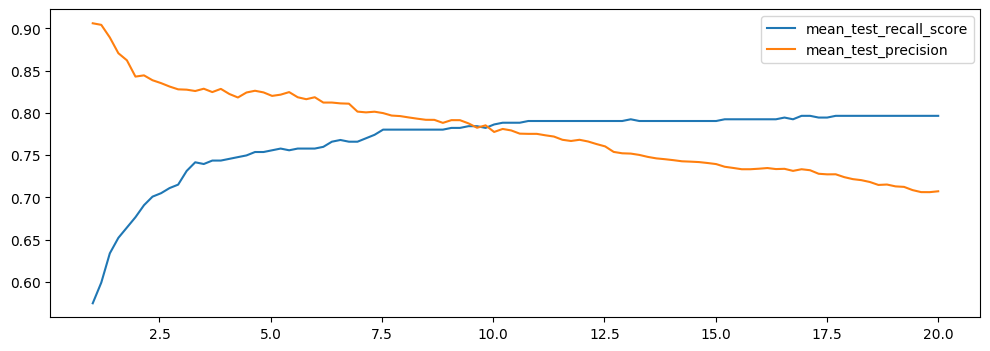

In [165]:
plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall_score', 'mean_test_precision']:
    plt.plot([_[1] for _ in df['param_class_weight']], df[score], label=score)
plt.legend()
plt.show()

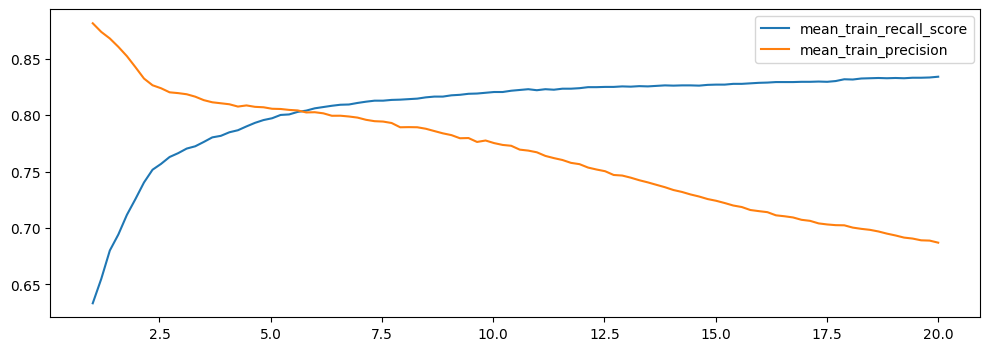

In [166]:
plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_train_recall_score', 'mean_train_precision']:
    plt.plot([_[1] for _ in df['param_class_weight']], df[score], label=score)
plt.legend()
plt.show()

#### Custom scoring function

In [174]:
from sklearn.metrics import precision_score, recall_score, make_scorer
def min_precision_score(y_true, y_pred):
    recall:float = float(recall_score(y_true=y_true, y_pred=y_pred))
    precision:float = float(precision_score(y_true=y_true, y_pred=y_pred))
    return min(recall, precision)

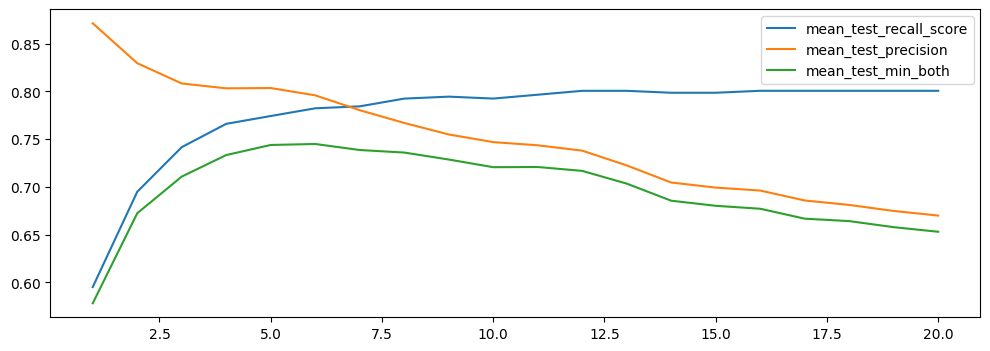

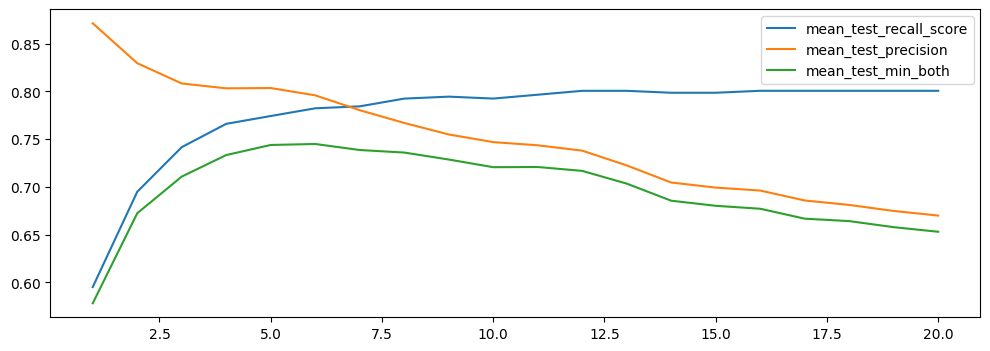

In [175]:
grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid={
        'class_weight': [{0: 1, 1: v} for v in np.linspace(1, 20, 20)]
    },
    cv=5,
    n_jobs=-1,
    scoring={
        'precision':make_scorer(precision_score), 
        'recall_score': make_scorer(recall_score),
        'min_both': make_scorer(min_precision_score)
    },
    refit="min_both",
    return_train_score=True
)


grid.fit(X, y)


plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall_score', 'mean_test_precision', "mean_test_min_both"]:
    plt.plot([_[1] for _ in df['param_class_weight']], df[score], label=score)
plt.legend()
plt.show()
plt.close()

plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall_score', 'mean_test_precision', "mean_test_min_both"]:
    plt.plot([_[1] for _ in df['param_class_weight']], df[score], label=score)
plt.legend()
plt.show()
plt.close()

We cas dispose of make_scorer by changing the structure of the estimator function

In [185]:
dataset = pd.read_csv(csv_path)

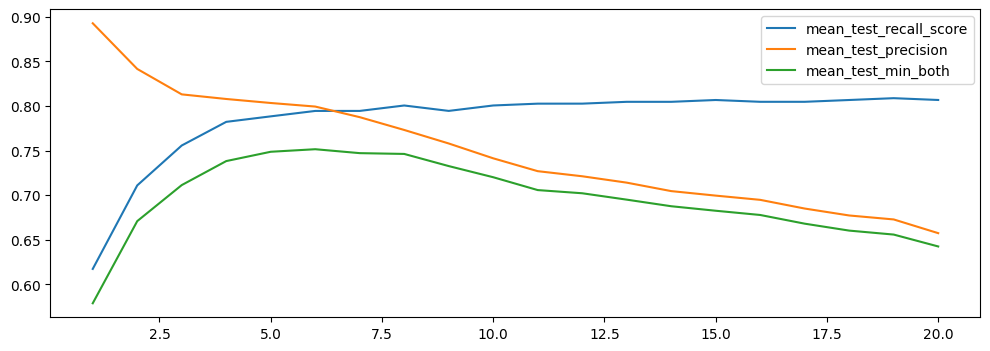

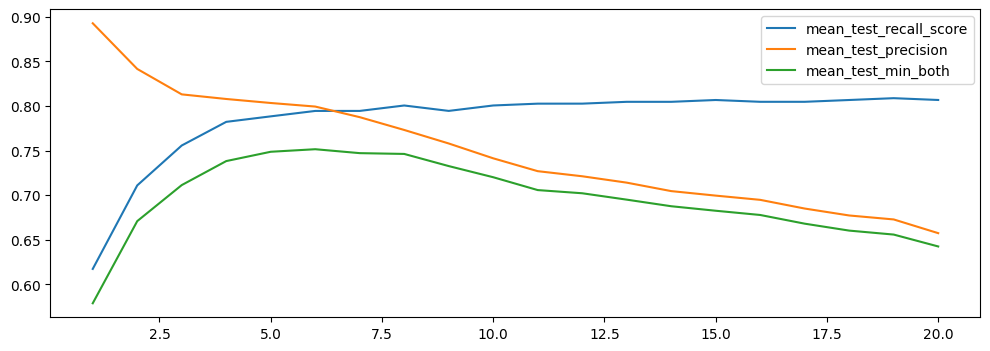

In [189]:
from sklearn.metrics import precision_score, recall_score, make_scorer


def min_precision_score(est, X, y_true, sample_weight=None):
    y_pred = est.predict(X)
    recall:float = float(recall_score(y_true=y_true, y_pred=y_pred, sample_weight=sample_weight))
    precision:float = float(precision_score(y_true=y_true, y_pred=y_pred, sample_weight=sample_weight))
    return min(recall, precision)


grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid={
        'class_weight': [{0: 1, 1: v} for v in np.linspace(1, 20, 20)]
    },
    cv=5,
    n_jobs=-1,
    scoring={
        'precision':make_scorer(precision_score), 
        'recall_score': make_scorer(recall_score),
        'min_both': min_precision_score
    },
    refit="min_both",
    return_train_score=True
)


grid.fit(X, y, sample_weight=np.log(1 + dataset['Amount']))


plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall_score', 'mean_test_precision', "mean_test_min_both"]:
    plt.plot([_[1] for _ in df['param_class_weight']], df[score], label=score)
plt.legend()
plt.show()
plt.close()

plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall_score', 'mean_test_precision', "mean_test_min_both"]:
    plt.plot([_[1] for _ in df['param_class_weight']], df[score], label=score)
plt.legend()
plt.show()
plt.close()

## Outlier detector

In [192]:
from sklearn.ensemble import IsolationForest
mod = IsolationForest().fit(X)
np.where(mod.predict(X) == -1, 1, 0)

array([0, 0, 0, ..., 0, 0, 0])

In [194]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer
from sklearn.linear_model import LogisticRegression
import numpy as np

def outlier_precision(mod, X, y):
    return precision_score(
        y_true= y,
        y_pred= np.where(mod.predict(X) == -1, 1, 0)
    )


def outlier_recall(mod, X, y):
    return recall_score(
        y_true= y,
        y_pred= np.where(mod.predict(X) == -1, 1, 0)
    )


grid = GridSearchCV(
    estimator=IsolationForest(),
    param_grid={'contamination': np.linspace(0.001, 0.02, 10)},
    scoring={
        'precision': outlier_precision,
        'recall': outlier_recall
    },
    refit='precision',
    cv=5,
    n_jobs=-1
)
grid.fit(X, y)

GridSearchCV(cv=5, estimator=IsolationForest(), n_jobs=-1,
             param_grid={'contamination': array([0.001     , 0.00311111, 0.00522222, 0.00733333, 0.00944444,
       0.01155556, 0.01366667, 0.01577778, 0.01788889, 0.02      ])},
             refit='precision',
             scoring={'precision': <function outlier_precision at 0x17beb5dc0>,
                      'recall': <function outlier_recall at 0x177079c10>})

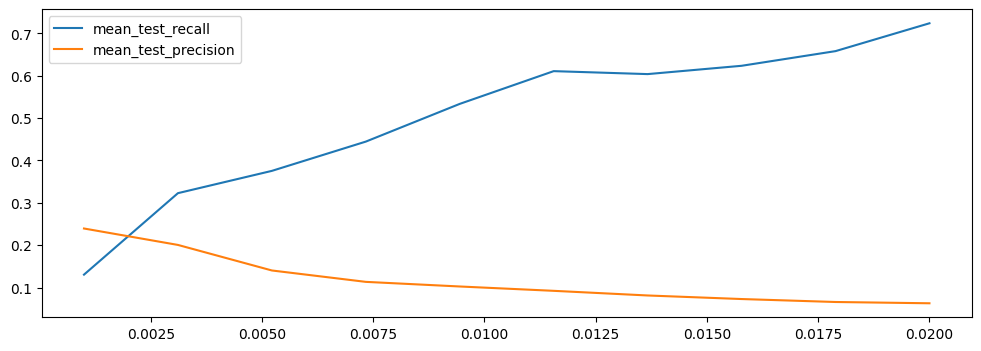

In [198]:
plt.figure(figsize=(12, 4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall', 'mean_test_precision']:
    plt.plot(df['param_contamination'], df[score], label=score)
plt.legend()
plt.show()
plt.close()